# 03 — Search readout: reading the leaderboard, choosing a config

**Milestone 4.** The disciplined search (`python -m src.harness.run_session`) ran 12 pre-registered configs, three seeds each, and appended them to `outputs/experiments/log.jsonl`. This notebook is the **human readout**: rank the log, see what the hyperparameters do, choose a config with reasoning, and report the one-time locked-holdout confirmation.

Nothing here trains a model or touches the locked holdout — it reads the frozen runner's log. Promotion is a human decision recorded in [`decisions.md`](../decisions.md).

In [1]:
import sys, json
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
from src import plotting as viz
from src.utils import EXPERIMENTS_DIR

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
K = 10
POP_NDCG = 0.063  # popularity baseline NDCG@10 (computed in notebook 02)

rows = [json.loads(l) for l in (EXPERIMENTS_DIR / 'log.jsonl').read_text().splitlines()]
df = pd.DataFrame([{
    'tag': r['tag'], 'factors': r['factors'], 'reg': r['regularization'],
    'iters': r['iterations'], 'alpha': r['alpha'],
    'ndcg': r['metrics'][f'ndcg@{K}']['mean'], 'ndcg_std': r['metrics'][f'ndcg@{K}']['std'],
    'precision': r['metrics'][f'precision@{K}']['mean'], 'recall': r['metrics'][f'recall@{K}']['mean'],
    'coverage': r['metrics'][f'coverage@{K}']['mean'],
} for r in rows])
# log.jsonl is append-only; if the session was re-run, keep the latest row per
# config (same factors/reg/iters/alpha) so the readout is robust to re-runs.
df = df.drop_duplicates(subset=['factors', 'reg', 'iters', 'alpha'], keep='last').reset_index(drop=True)
print(f'{len(df)} unique configs, {rows[0]["n_seeds"]} seeds each')

12 unique configs, 3 seeds each


## The leaderboard

In [2]:
lb = df.sort_values('ndcg', ascending=False).reset_index(drop=True)
lb.round(4)

,tag,factors,reg,iters,alpha,ndcg,ndcg_std,precision,recall,coverage
0,alpha1_f24,24,0.010,15,1.0,0.1712,0.0031,0.1312,0.1665,0.0323
1,alpha1_f32,32,0.010,15,1.0,0.1710,0.0006,0.1317,0.1672,0.0379
2,alpha1_f16,16,0.010,15,1.0,0.1689,0.0003,0.1285,0.1631,0.0254
3,alpha1_f64,64,0.010,15,1.0,0.1571,0.0005,0.1207,0.1530,0.0558
4,alpha3_f64,64,0.010,15,3.0,0.1534,0.0014,0.1176,0.1493,0.0747
5,alpha1_f128_reg.001,128,0.001,15,1.0,0.1383,0.0012,0.1049,0.1327,0.0857
6,alpha1_f128,128,0.010,15,1.0,0.1381,0.0011,0.1049,0.1326,0.0860
7,alpha1_f128_iters30,128,0.010,30,1.0,0.1381,0.0008,0.1054,0.1331,0.0872
8,baseline,64,0.010,15,10.0,0.1376,0.0018,0.1068,0.1358,0.0921
9,alpha1_f128_reg.1,128,0.100,15,1.0,0.1376,0.0010,0.1048,0.1323,0.0855


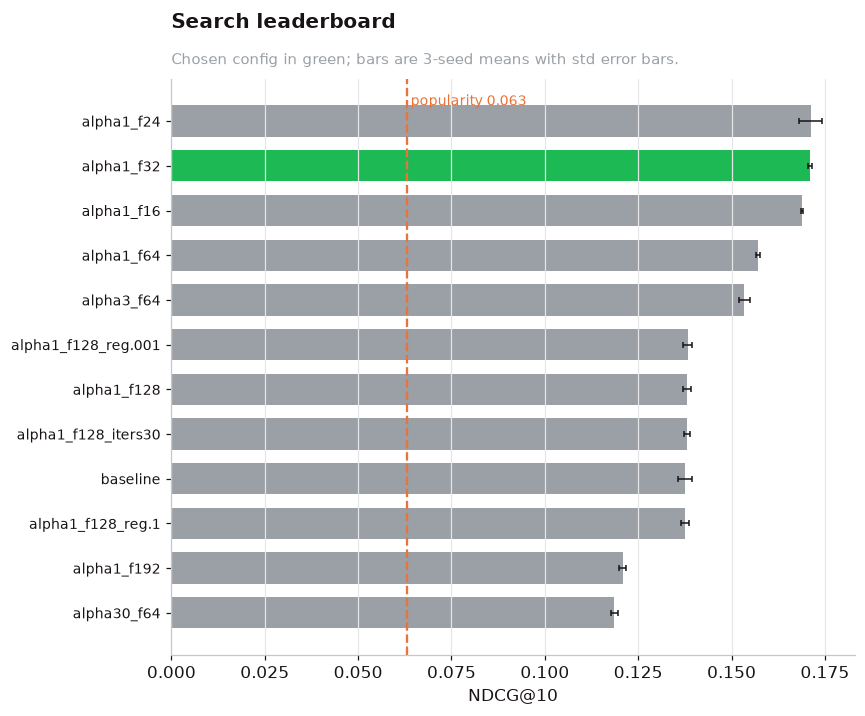

In [3]:
_ = viz.plot_leaderboard(df['tag'].tolist(), df['ndcg'].tolist(), df['ndcg_std'].tolist(),
                         chosen='alpha1_f32', baseline=POP_NDCG, k=K,
                         save_path=FIG / 'search_leaderboard.png')

### The full metric picture — what the leaderboard hides

We *selected* on NDCG@10, but the runner logged the whole suite for every config. Looking at all of it shows the tradeoffs a single column hides — in particular, that the accuracy metrics all agree while the beyond-accuracy metrics move the other way.

In [4]:
def m(r, key):
    return r['metrics'][key]['mean']

rich = pd.DataFrame([{
    'tag': r['tag'], 'factors': r['factors'], 'reg': r['regularization'],
    'iters': r['iterations'], 'alpha': r['alpha'],
    'NDCG@10': m(r, 'ndcg@10'), 'MAP@10': m(r, 'map@10'), 'MRR@10': m(r, 'mrr@10'),
    'recall@10': m(r, 'recall@10'), 'coverage': m(r, 'coverage@10'),
    'novelty': m(r, 'novelty'), 'Gini': m(r, 'gini'),
} for r in rows]).drop_duplicates(['factors', 'reg', 'iters', 'alpha'], keep='last')

# do the accuracy metrics agree on the ranking? (Spearman vs NDCG)
acc = rich[['NDCG@10', 'MAP@10', 'MRR@10', 'recall@10']].corr(method='spearman')['NDCG@10']
print('Spearman rank-correlation with NDCG@10:')
for k, v in acc.items():
    print(f'  {k:<11} {v:+.3f}')
print(f"\n  novelty  vs NDCG@10: {rich['novelty'].corr(rich['NDCG@10'], method='spearman'):+.3f}  "
      f"(beyond-accuracy moves the OTHER way)")
rich.sort_values('NDCG@10', ascending=False)[
    ['tag', 'NDCG@10', 'MAP@10', 'MRR@10', 'recall@10', 'coverage', 'novelty', 'Gini']].round(4)

Spearman rank-correlation with NDCG@10:
  NDCG@10     +1.000
  MAP@10      +1.000
  MRR@10      +0.979
  recall@10   +0.923



  novelty  vs NDCG@10: -0.797  (beyond-accuracy moves the OTHER way)


,tag,NDCG@10,MAP@10,MRR@10,recall@10,coverage,novelty,Gini
5,alpha1_f24,0.1712,0.0813,0.3579,0.1665,0.0323,4.3383,0.9883
6,alpha1_f32,0.1710,0.0810,0.3557,0.1672,0.0379,4.4531,0.9864
4,alpha1_f16,0.1689,0.0805,0.3553,0.1631,0.0254,4.1591,0.9909
1,alpha1_f64,0.1571,0.0733,0.3324,0.1530,0.0558,4.8249,0.9796
2,alpha3_f64,0.1534,0.0710,0.3292,0.1493,0.0747,4.9621,0.9750
9,alpha1_f128_reg.001,0.1383,0.0624,0.3079,0.1327,0.0857,5.3134,0.9680
7,alpha1_f128,0.1381,0.0623,0.3076,0.1326,0.0860,5.3171,0.9679
11,alpha1_f128_iters30,0.1381,0.0622,0.3051,0.1331,0.0872,5.3475,0.9671
0,baseline,0.1376,0.0621,0.2975,0.1358,0.0921,5.1081,0.9704
10,alpha1_f128_reg.1,0.1376,0.0620,0.3058,0.1323,0.0855,5.3266,0.9677


All four accuracy metrics rank the configs almost identically (Spearman near +1) — so the choice is not an artefact of picking NDCG specifically. Meanwhile **novelty is anti-correlated with accuracy**: the configs that score best recommend the *least* novel artists. The search optimised accuracy and, in doing so, implicitly chose low novelty / high concentration. That tradeoff is now explicit in the log rather than buried — and it is exactly what the `diversity` knob on the API exists to dial back.

## Is a 3-seed check enough? Seed noise vs config gaps

The sparsity investigation predicted we would not need the FPD project's many-seed stability machinery. We can verify that directly: if the seed-to-seed wobble of a single config is small next to the gaps *between* configs, then three seeds already resolve the ranking.

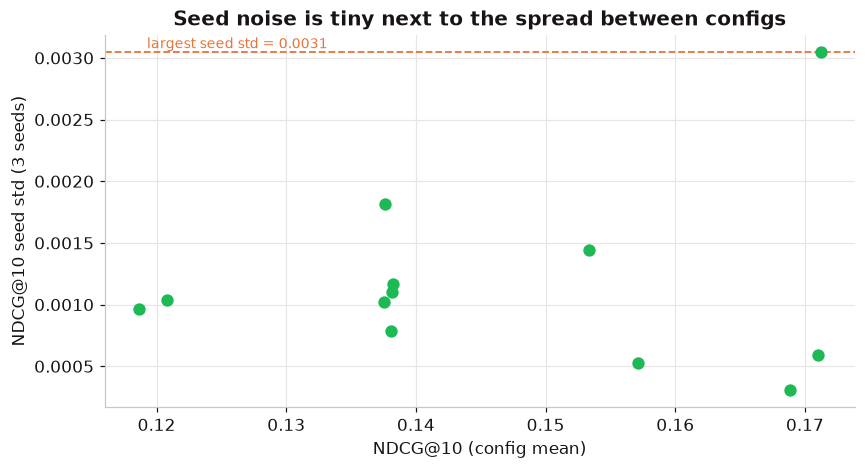

NDCG@10 spread across configs : 0.053
largest single-config seed std: 0.0031  (~6% of the spread)
=> three seeds resolve the ranking; the heavy stability apparatus would add cost, not information.


In [5]:
import matplotlib.pyplot as plt

spread = df['ndcg'].max() - df['ndcg'].min()
max_std = df['ndcg_std'].max()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.scatter(df['ndcg'], df['ndcg_std'], s=50, color=viz.GREEN, zorder=3)
ax.axhline(max_std, color=viz.ACCENT, ls='--', lw=1.2)
ax.text(df['ndcg'].min(), max_std, f'  largest seed std = {max_std:.4f}', color=viz.ACCENT,
        fontsize=9, va='bottom')
ax.set(title='Seed noise is tiny next to the spread between configs',
       xlabel='NDCG@10 (config mean)', ylabel='NDCG@10 seed std (3 seeds)')
fig.tight_layout(); fig.savefig(FIG / 'search_seed_stability.png'); plt.show()

print(f'NDCG@10 spread across configs : {spread:.3f}')
print(f'largest single-config seed std: {max_std:.4f}  '
      f'(~{max_std/spread*100:.0f}% of the spread)')
print('=> three seeds resolve the ranking; the heavy stability apparatus would add cost, not information.')

## What the hyperparameters do

**Capacity (factors).** Holding alpha=1, reg=0.01, iters=15, sweep factors. Low capacity wins — the model wants to be small on this sparse data.

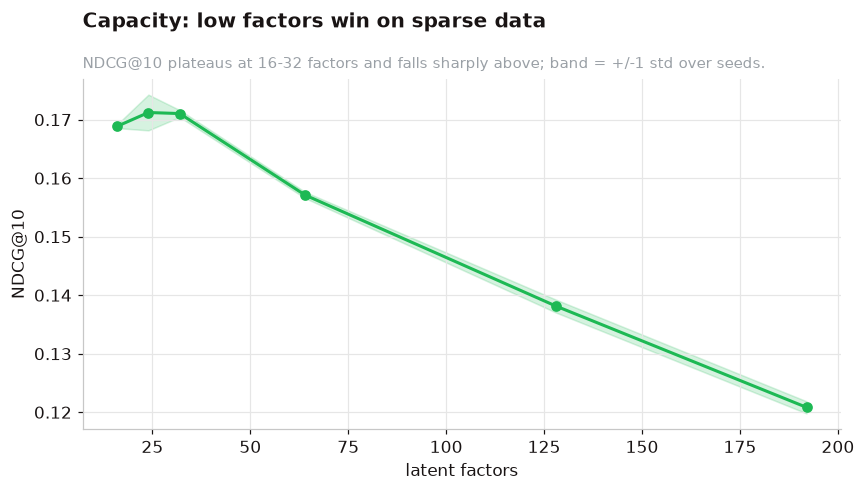

In [6]:
fac = df[(df.alpha == 1.0) & (df.reg == 0.01) & (df.iters == 15)].sort_values('factors')
_ = viz.plot_metric_by_param(fac['factors'], fac['ndcg'], fac['ndcg_std'],
                             xlabel='latent factors', title='Capacity: low factors win on sparse data',
                             subtitle='NDCG@10 plateaus at 16-32 factors and falls sharply above; band = +/-1 std over seeds.',
                             save_path=FIG / 'search_factors.png')

**Confidence (alpha).** Holding factors=64, sweep alpha. Lower is better — heavy log-confidence scaling hurts.

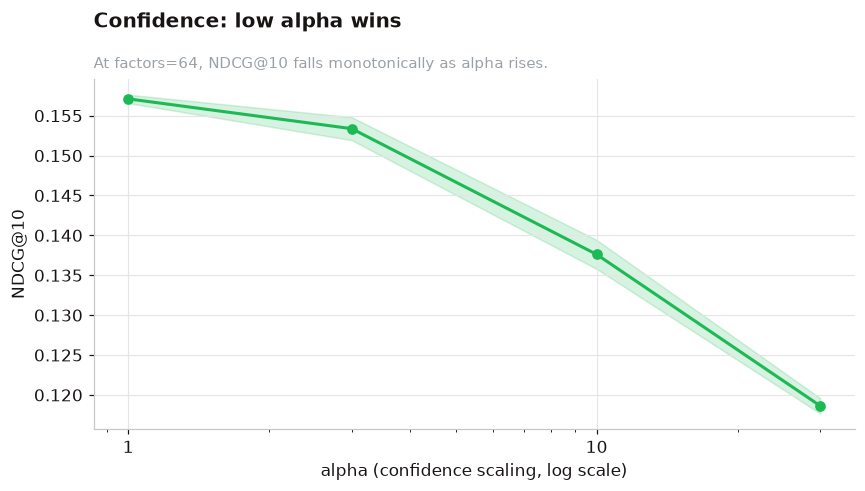

In [7]:
al = df[(df.factors == 64) & (df.reg == 0.01) & (df.iters == 15)].sort_values('alpha')
_ = viz.plot_metric_by_param(al['alpha'], al['ndcg'], al['ndcg_std'], logx=True,
                             xlabel='alpha (confidence scaling, log scale)',
                             title='Confidence: low alpha wins',
                             subtitle='At factors=64, NDCG@10 falls monotonically as alpha rises.',
                             save_path=FIG / 'search_alpha.png')

**The accuracy vs coverage tradeoff.** Each config is a point: higher coverage (more of the long-tail catalogue recommended) tends to come with lower NDCG.

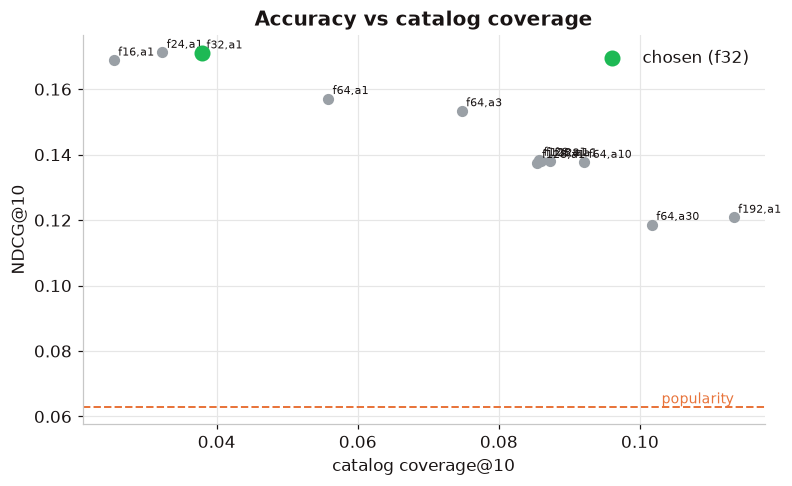

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(df['coverage'], df['ndcg'], s=40, color=viz.MUTED, zorder=3)
chosen = df[df.tag == 'alpha1_f32'].iloc[0]
ax.scatter([chosen['coverage']], [chosen['ndcg']], s=90, color=viz.GREEN, zorder=4, label='chosen (f32)')
for _, r in df.iterrows():
    ax.annotate(f"f{r['factors']},a{r['alpha']:g}", (r['coverage'], r['ndcg']),
                fontsize=7, color=viz.DARK, xytext=(3, 3), textcoords='offset points')
ax.axhline(POP_NDCG, color=viz.ACCENT, ls='--', lw=1.3)
ax.text(df['coverage'].max(), POP_NDCG, ' popularity', color=viz.ACCENT, fontsize=9, va='bottom', ha='right')
ax.legend(frameon=False)
ax.set(title='Accuracy vs catalog coverage', xlabel='catalog coverage@10', ylabel='NDCG@10')
fig.savefig(FIG / 'search_accuracy_coverage.png'); plt.show()

## The choice, and the reasoning

The nominal top two — **f24 (0.1712 +/- 0.0031)** and **f32 (0.1710 +/- 0.0006)** — are a statistical tie (overlapping bands), and with f16 they form a plateau before quality drops sharply at 64+ factors. Per `program.md`'s acceptance rule (overlapping bands = no real difference; break ties toward the stabler/simpler model), the chosen config is:

> **factors = 32, regularization = 0.01, iterations = 15, alpha = 1.0**  (log1p confidence)

f32's seed band is ~5x tighter than f24's at essentially the same mean — the more credible pick. It beats the popularity baseline (0.063) by ~2.7x. Recorded in `decisions.md` and promoted into `search_config.CONFIG`.

### Locked-holdout confirmation (read once)

`python -m src.harness.confirm_holdout` trained the chosen config on the full search pool (74,265 interactions) and scored it on the sealed holdout:

| metric | locked holdout |
|---|---|
| NDCG@10 | **0.2330 +/- 0.0006** |
| precision@10 | 0.1930 |
| recall@10 | 0.1963 |

Higher than CV (0.171) — expected, because the holdout model sees more training data and holdout users have more held-out items. The config generalises with no sign of overfitting. The holdout has now been read once; that act is recorded in `decisions.md`.

## Summary

- The search is small, pre-registered, seed-checked, and human-gated — auditable, not a roam.
- Sparse data rewards a **small** model (32 factors, alpha=1); capacity and confidence both hurt past their sweet spot.
- Chosen config: NDCG@10 0.171 (CV) / 0.233 (holdout), ~2.7x popularity.
- A real accuracy/coverage tradeoff exists and is flagged for the product decision.

Next: **Milestone 5** (model card) and **Milestone 6** (FastAPI service that serves this config, with the cold-start fallback).